In [28]:
import os
import pandas as pd
import numpy as np
path = os.path.join( "..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.72      0.79      0.75     65070
           2       0.70      0.50      0.58     61671
           3       0.42      0.35      0.38     23801
           4       0.11      0.52      0.18      4110

    accuracy                           0.60    154652
   macro avg       0.49      0.54      0.48    154652
weighted avg       0.65      0.60      0.61    154652



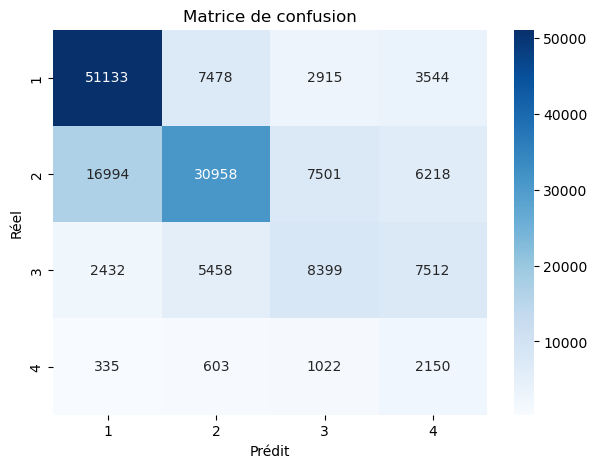

In [37]:
##############
# Logistic Regression with SMOTETomek
##############

from sklearn.preprocessing import MultiLabelBinarizer

# === 1. Split data
X = df.drop(columns=['grav'])  
y = df['grav']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f'eq_{str(c)}' for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f'eq_{str(c)}' for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

# Colonnes
equip_cols = list(equip_train.columns)
cols_to_exclude = ['com'] + equip_cols
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['com'])
], remainder='passthrough')

from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from imblearn.combine import SMOTETomek

pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('resampling', SMOTETomek(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.72      0.78      0.75     65070
           2       0.69      0.51      0.59     61671
           3       0.42      0.34      0.38     23801
           4       0.11      0.55      0.19      4110

    accuracy                           0.60    154652
   macro avg       0.49      0.54      0.47    154652
weighted avg       0.65      0.60      0.61    154652



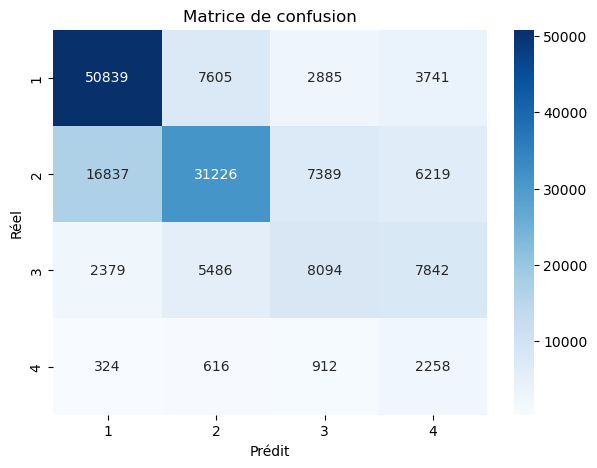

In [ ]:
##############
# Logistic Regression with under-sampling
##############
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['grav'])  
y = df['grav']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f'eq_{str(c)}' for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f'eq_{str(c)}' for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)



# Colonnes
equip_cols = list(equip_train.columns)
cols_to_exclude = ['com'] + equip_cols
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['com'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

              precision    recall  f1-score   support

           1       0.73      0.71      0.72     65070
           2       0.64      0.48      0.55     61671
           3       0.35      0.38      0.36     23801
           4       0.11      0.54      0.18      4110

    accuracy                           0.56    154652
   macro avg       0.46      0.52      0.45    154652
weighted avg       0.62      0.56      0.58    154652



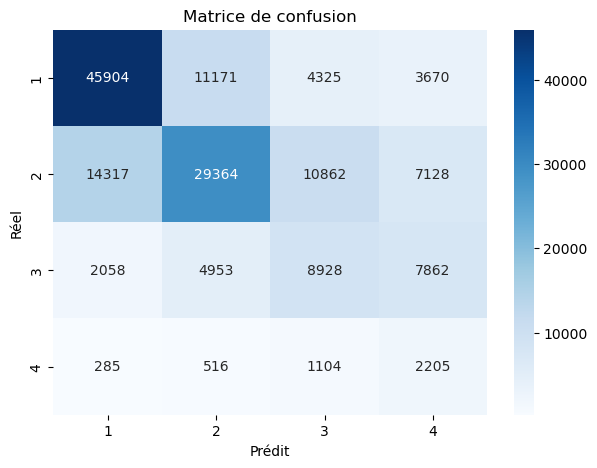

In [38]:
##############
# Random Forest with under-sampling
##############
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['grav'])  
y = df['grav']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f'eq_{str(c)}' for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f'eq_{str(c)}' for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)



# Colonnes
equip_cols = list(equip_train.columns)
cols_to_exclude = ['com'] + equip_cols
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['com'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/preprocessing/_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:08:12] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/preprocessing/_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))


              precision    recall  f1-score   support

           0       0.74      0.76      0.75     65070
           1       0.69      0.49      0.57     61671
           2       0.39      0.41      0.40     23801
           3       0.12      0.56      0.20      4110

    accuracy                           0.59    154652
   macro avg       0.48      0.55      0.48    154652
weighted avg       0.65      0.59      0.61    154652



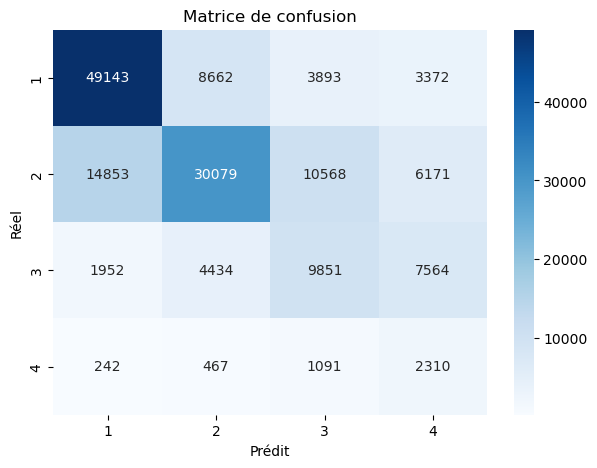

In [66]:
##############
# XG Boost with under-sampling
##############


import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer


# === 1. Chargement des données
path = os.path.join("..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

# === 2. Split
X = df.drop(columns=['grav'])
y = df['grav']

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y = [1, 2, 3, 4] ➜ y_encoded = [0, 1, 2, 3]


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)



# === 3. Encodage 'equipements' avec MultiLabelBinarizer (version corrigée)
empty_count = 0  # Compteur global pour les noms vides

def clean_col(col):
    s = (
        str(col)
        .replace('[', '')
        .replace(']', '')
        .replace('<', '')
        .replace('>', '')
        .replace(' ', '_')
        .replace(',', '_')
        .replace('.', '_')
        .replace('=', '_')
        .replace('__', '_')
    )
    s = s.strip('_')
    if not s:
        global empty_count
        empty_count += 1
        s = f'empty_{empty_count}'
    return s

mlb = MultiLabelBinarizer()
# Réinitialiser le compteur avant chaque utilisation
empty_count = 0

mlb.fit(X_train['equipements'])

cleaned_columns = [f"eq_{clean_col(c)}" for c in mlb.classes_]

equip_train = pd.DataFrame(
    mlb.transform(X_train['equipements']),
    columns=cleaned_columns,
    index=X_train.index
)

if equip_train.columns.duplicated().any():
    print("Attention, colonnes dupliquées dans equip_train :", equip_train.columns[equip_train.columns.duplicated()])


# Reutilise exactement les mêmes noms pour le test :
equip_test = pd.DataFrame(
    mlb.transform(X_test['equipements']),
    columns=cleaned_columns,
    index=X_test.index
)

assert list(equip_train.columns) == list(equip_test.columns)


# Ajout au dataset
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)

# === 4. TargetEncoding sur 'com'
te = TargetEncoder()
X_train['com_encoded'] = te.fit_transform(X_train['com'], y_train)
X_test['com_encoded'] = te.transform(X_test['com'])
X_train.drop(columns='com', inplace=True)
X_test.drop(columns='com', inplace=True)

# === 5. Colonnes à OHE
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]


# === 6. Pipeline de préprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
    ],
    remainder='passthrough',
    verbose_feature_names_out=True
)


# === 7. Pipeline complète avec XGBoost et undersampling
# === 6. Pipeline complète avec conversion en array

def convert_to_array(X):
    return np.asarray(X, dtype=np.float32)

pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('to_array', FunctionTransformer(convert_to_array, validate=False)),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# === 8. Entraînement
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_pred_original = le.inverse_transform(y_pred)  # retourne [1, 2, 3, 4]


# === 9. Évaluation
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()



/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/preprocessing/_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:16:25] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/preprocessing/_function_transformer.py:311: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))


🔍 Évaluation avec seuil 0.25 pour la classe 4 :
              precision    recall  f1-score   support

           1       0.74      0.74      0.74     65070
           2       0.69      0.46      0.55     61671
           3       0.34      0.20      0.25     23801
           4       0.09      0.77      0.16      4110

    accuracy                           0.55    154652
   macro avg       0.47      0.54      0.43    154652
weighted avg       0.64      0.55      0.58    154652

🔍 Évaluation standard :
              precision    recall  f1-score   support

           1       0.74      0.76      0.75     65070
           2       0.69      0.49      0.57     61671
           3       0.39      0.41      0.40     23801
           4       0.12      0.56      0.20      4110

    accuracy                           0.59    154652
   macro avg       0.48      0.55      0.48    154652
weighted avg       0.65      0.59      0.61    154652



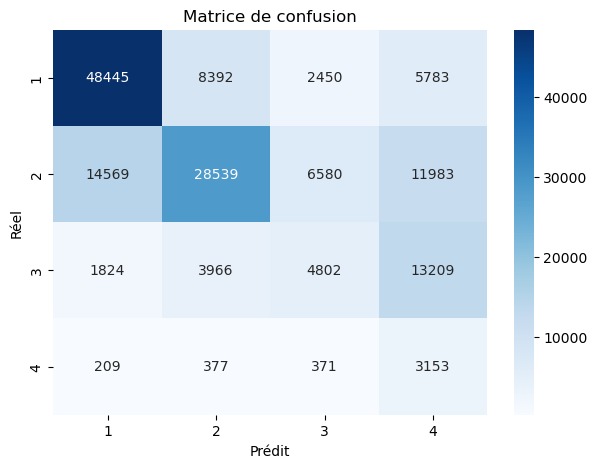

In [69]:
##############
# XG Boost with under-sampling
##############


import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer


# === 1. Chargement des données
path = os.path.join("..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

# === 2. Split
X = df.drop(columns=['grav'])
y = df['grav']

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y = [1, 2, 3, 4] ➜ y_encoded = [0, 1, 2, 3]


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)



# === 3. Encodage 'equipements' avec MultiLabelBinarizer (version corrigée)
empty_count = 0  # Compteur global pour les noms vides

def clean_col(col):
    s = (
        str(col)
        .replace('[', '')
        .replace(']', '')
        .replace('<', '')
        .replace('>', '')
        .replace(' ', '_')
        .replace(',', '_')
        .replace('.', '_')
        .replace('=', '_')
        .replace('__', '_')
    )
    s = s.strip('_')
    if not s:
        global empty_count
        empty_count += 1
        s = f'empty_{empty_count}'
    return s

mlb = MultiLabelBinarizer()
# Réinitialiser le compteur avant chaque utilisation
empty_count = 0

mlb.fit(X_train['equipements'])

cleaned_columns = [f"eq_{clean_col(c)}" for c in mlb.classes_]

equip_train = pd.DataFrame(
    mlb.transform(X_train['equipements']),
    columns=cleaned_columns,
    index=X_train.index
)

if equip_train.columns.duplicated().any():
    print("Attention, colonnes dupliquées dans equip_train :", equip_train.columns[equip_train.columns.duplicated()])


# Reutilise exactement les mêmes noms pour le test :
equip_test = pd.DataFrame(
    mlb.transform(X_test['equipements']),
    columns=cleaned_columns,
    index=X_test.index
)

assert list(equip_train.columns) == list(equip_test.columns)


# Ajout au dataset
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)

# === 4. TargetEncoding sur 'com'
te = TargetEncoder()
X_train['com_encoded'] = te.fit_transform(X_train['com'], y_train)
X_test['com_encoded'] = te.transform(X_test['com'])
X_train.drop(columns='com', inplace=True)
X_test.drop(columns='com', inplace=True)

# === 5. Colonnes à OHE
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]


# === 6. Pipeline de préprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
    ],
    remainder='passthrough',
    verbose_feature_names_out=True
)


# === 7. Pipeline complète avec XGBoost et undersampling
# === 6. Pipeline complète avec conversion en array

def convert_to_array(X):
    return np.asarray(X, dtype=np.float32)

pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('to_array', FunctionTransformer(convert_to_array, validate=False)),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# === 8. Entraînement
pipeline.fit(X_train, y_train)
# Probabilités
probas = pipeline.predict_proba(X_test)

# 🔧 Fonction pour appliquer un seuil personnalisé à la classe 3 (index de classe 4)
def predict_with_custom_threshold(probas, target_class_index, threshold):
    y_pred = []
    for p in probas:
        if p[target_class_index] > threshold:
            y_pred.append(target_class_index)
        else:
            p_copy = p.copy()
            p_copy[target_class_index] = 0
            y_pred.append(np.argmax(p_copy))
    return np.array(y_pred)

# Prédiction avec seuil à 0.25 pour classe 4 (index 3)
y_pred_custom = predict_with_custom_threshold(probas, target_class_index=3, threshold=0.25)
y_pred = np.argmax(probas, axis=1)

# 💡 Revenir à labels originaux (1 à 4)
y_test_true = le.inverse_transform(y_test)
y_pred_true = le.inverse_transform(y_pred)
y_pred_custom_true = le.inverse_transform(y_pred_custom)

# 🎯 Évaluation
print("🔍 Évaluation avec seuil 0.25 pour la classe 4 :")
print(classification_report(y_test_true, y_pred_custom_true))
print("🔍 Évaluation standard :")
print(classification_report(y_test_true, y_pred_true))

# 🔢 Matrice de confusion
cm = confusion_matrix(y_test_true, y_pred_custom_true)
classes = le.classes_

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

